<a href="https://colab.research.google.com/github/Yaswanth-k-REDDY/netflix/blob/master/intern_task1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None

--- Missing Values Count ---
survived         0
pcla

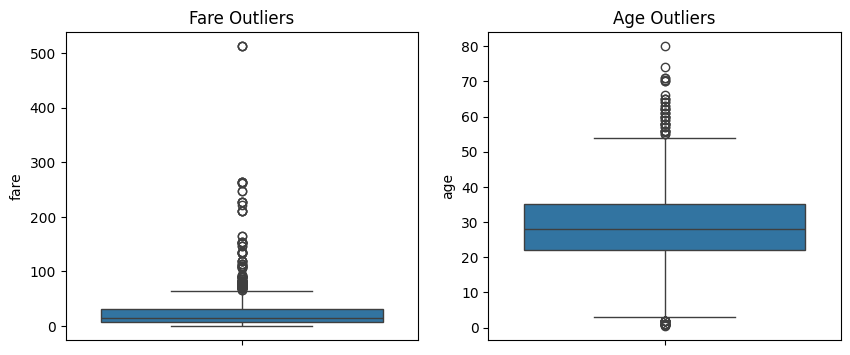

Shape change: (891, 15) -> (775, 15)

--- Final Preprocessed Data Sample ---
        age      fare
0 -0.528321 -0.779117
2 -0.215182 -0.729373
3  0.489381  2.599828
4  0.489381 -0.720161
5 -0.058613 -0.690071


/tmp/ipykernel_13823/3278444798.py:67: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean[num_cols] = scaler.fit_transform(df_clean[num_cols])


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Titanic dataset (using the online seaborn repository for ease)
df = sns.load_dataset('titanic')

# Display basic information about the dataset
print("--- Dataset Info ---")
print(df.info())

print("\n--- Missing Values Count ---")
print(df.isnull().sum())
# 1. Fill missing 'age' with the median age (robust to outliers)
df['age'] = df['age'].fillna(df['age'].median())

# 2. Fill missing 'embarked' with the mode (most frequent value)
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# 3. Drop columns with too many missing values to be useful
# 'deck' or 'cabin' usually has >70% missing values
df.drop(columns=['deck', 'alive', 'embarked_town'], inplace=True, errors='ignore')

print("Missing values after imputation:", df.isnull().sum().sum())
# Map 'sex' to 0 and 1
df['sex'] = df['sex'].map({'male': 0, 'female': 1})

# One-Hot Encode 'embarked' and 'class' columns
df = pd.get_dummies(df, columns=['embarked', 'class'], drop_first=True)

# Convert boolean columns (True/False from get_dummies) to 0/1
df = df.astype({col: 'int' for col in df.select_dtypes(include='bool').columns})

print(df.head())
# Visualize outliers before removal
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.boxplot(data=df, y='fare')
plt.title('Fare Outliers')

plt.subplot(1, 2, 2)
sns.boxplot(data=df, y='age')
plt.title('Age Outliers')
plt.show()

# Remove outliers for 'fare' using IQR
Q1 = df['fare'].quantile(0.25)
Q3 = df['fare'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter the dataframe
df_clean = df[(df['fare'] >= lower_bound) & (df['fare'] <= upper_bound)].copy()
print(f"Shape change: {df.shape} -> {df_clean.shape}")
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Select numerical columns to scale
num_cols = ['age', 'fare']

# Fit and transform
df_clean[num_cols] = scaler.fit_transform(df_clean[num_cols])

print("\n--- Final Preprocessed Data Sample ---")
print(df_clean[num_cols].head())